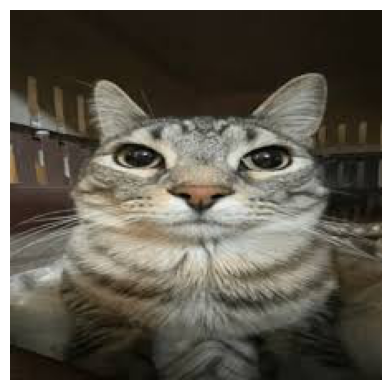

Image shape: (224, 225, 3)  |  dtype: uint8


In [17]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import io, base64
from IPython.display import display as ipy_display, HTML

IMG_PATH = 'cat.jpg'
img_color = np.array(Image.open(IMG_PATH))
img_gray  = np.array(Image.open(IMG_PATH).convert('L'))

plt.figure(figsize=(5,4))
plt.imshow(img_color)
plt.axis('off')
plt.tight_layout()
plt.show()
print(f'Image shape: {img_color.shape}  |  dtype: {img_color.dtype}')

### Task 1 – Color  Grayscale
Create a function that takes a **color image** as input and produces a grayscale output.

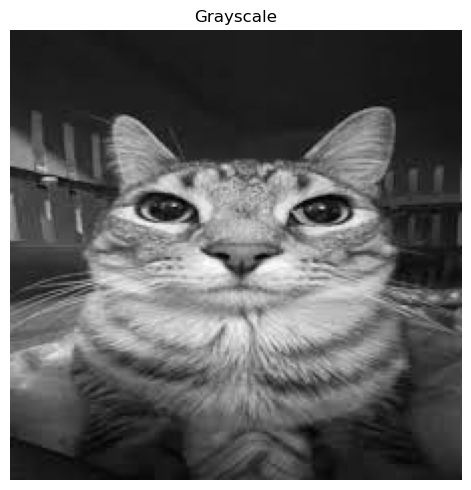

In [18]:
def color_to_gray(img):
    return np.array(Image.fromarray(img).convert('L'))

gray_out = color_to_gray(img_color)

plt.figure(figsize=(6, 5))
plt.imshow(gray_out, cmap='gray')
plt.title('Grayscale')
plt.axis('off')
plt.tight_layout()
plt.show()

### Task 2 – Mirror Effect
Create a function that produces a **mirror effect** by concatenating the original image with its
horizontally-flipped copy. MATLAB equivalent: `C = [A B]` where `B = fliplr(A)`.

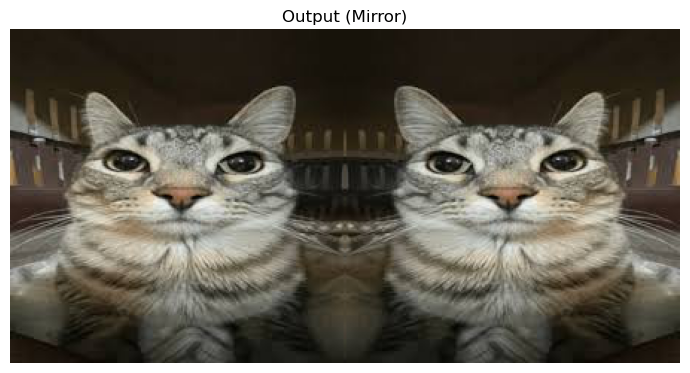

In [19]:
def mirror_effect(img):
    mirrored = np.fliplr(img)
    return np.concatenate([img, mirrored], axis=1)

mirror_out = mirror_effect(img_color)

plt.figure(figsize=(7, 5))
plt.imshow(mirror_out)
plt.title('Output (Mirror)')
plt.axis('off')
plt.tight_layout()
plt.show()

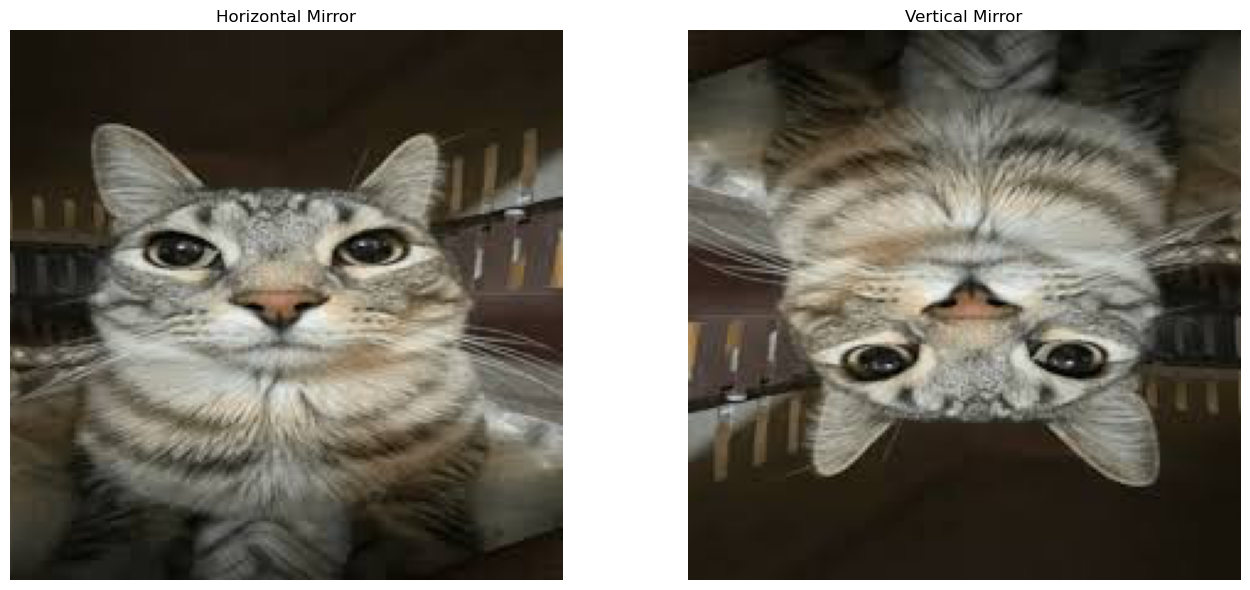

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(horizontal_out)
axes[0].set_title('Horizontal Mirror')
axes[0].axis('off')

axes[1].imshow(vertical_out)
axes[1].set_title('Vertical Mirror')
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## Section 2: Intensity Transformation

### Task 1 – Image Negative
Apply `s = L − 1 − r` to invert all pixel intensities.

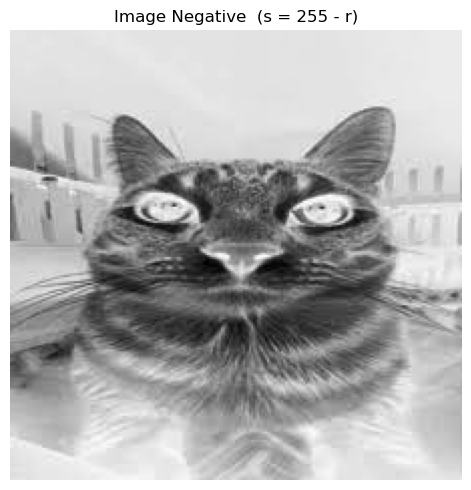

In [20]:
def image_negative(img):
    return 255 - img

neg_out = image_negative(img_gray)

plt.figure(figsize=(6, 5))
plt.imshow(neg_out, cmap='gray')
plt.title('Image Negative  (s = 255 - r)')
plt.axis('off')
plt.tight_layout()
plt.show()

### Task 2a – Gamma Curves: Non-Normalized (0–255)
Plot `s = r^γ` for γ ∈ {0.02, 0.2, 0.5, 0.8, 1, 2, 3, 3.5, 4} with `r` in the range 0–255.

> **Why curves don't meet at y = L−1 = 255?**  
> For γ > 1, the function `r^γ` grows faster than linearly, so `255^γ ≫ 255`.  
> The output values exceed 255, meaning the curves diverge and never converge at the top-right corner.

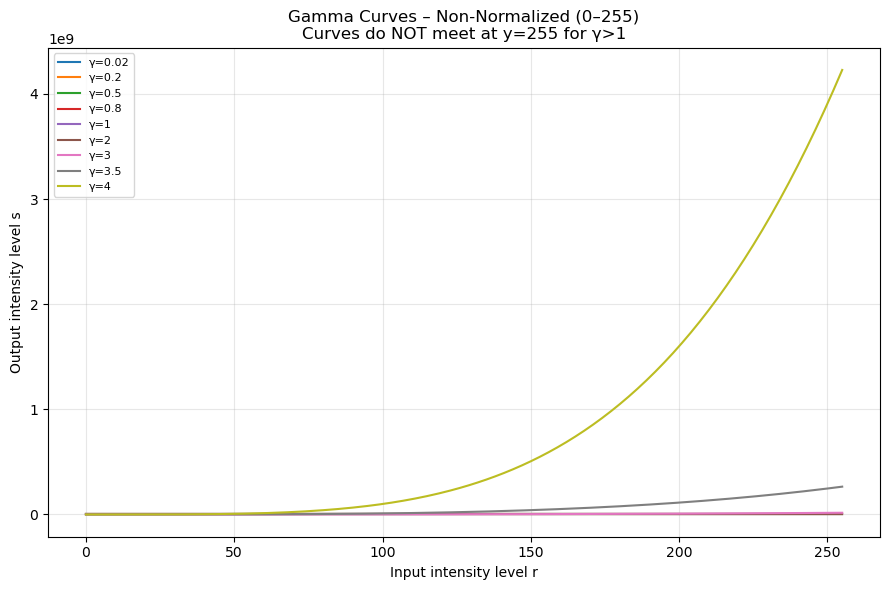

In [36]:
gammas = [0.02, 0.2, 0.5, 0.8, 1, 2, 3, 3.5, 4]
x = np.arange(0, 256)  # x = 0:255

plt.figure(figsize=(9, 6))
for g in gammas:
    plt.plot(x, x**g, label=f'γ={g}')
plt.xlabel('Input intensity level r')
plt.ylabel('Output intensity level s')
plt.title('Gamma Curves – Non-Normalized (0–255)\nCurves do NOT meet at y=255 for γ>1')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Task 2b – Gamma Curves: Normalized (0–1)
Plot `s = r^γ` with `r` normalized to [0, 1].

> **Why do all curves meet at y = 1?**  
> Because `1^γ = 1` for **any** value of γ. When the input range is [0, 1],  
> every gamma curve passes through the point (1, 1) regardless of γ.

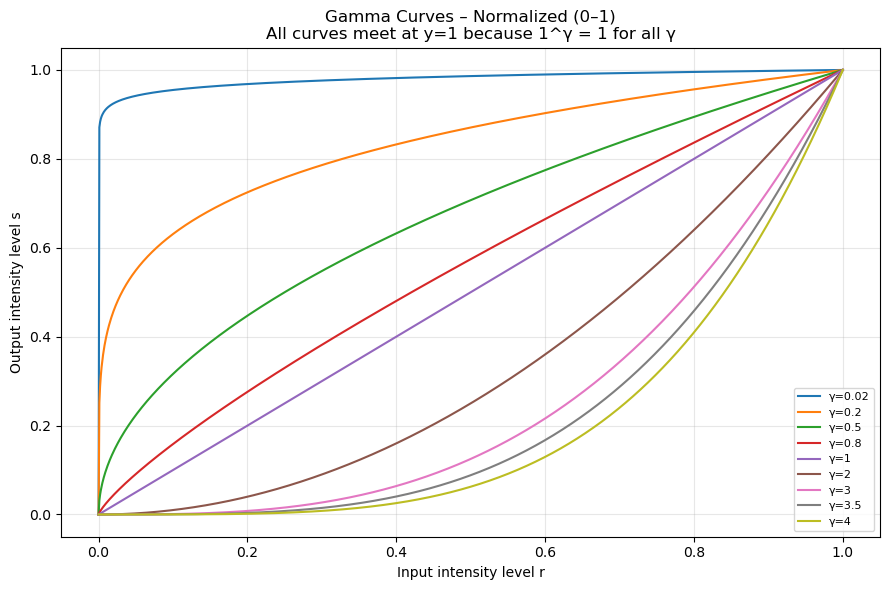

In [37]:
x_n = np.linspace(0, 1, 1001)  # x = 0:0.001:1

plt.figure(figsize=(9, 6))
for g in gammas:
    plt.plot(x_n, x_n**g, label=f'γ={g}')
plt.xlabel('Input intensity level r')
plt.ylabel('Output intensity level s')
plt.title('Gamma Curves – Normalized (0–1)\nAll curves meet at y=1 because 1^γ = 1 for all γ')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Task 3 – Apply Gamma Correction to Image
Apply gamma correction with γ = 0.5 (brightening), 1.0 (unchanged), and 2.0 (darkening).

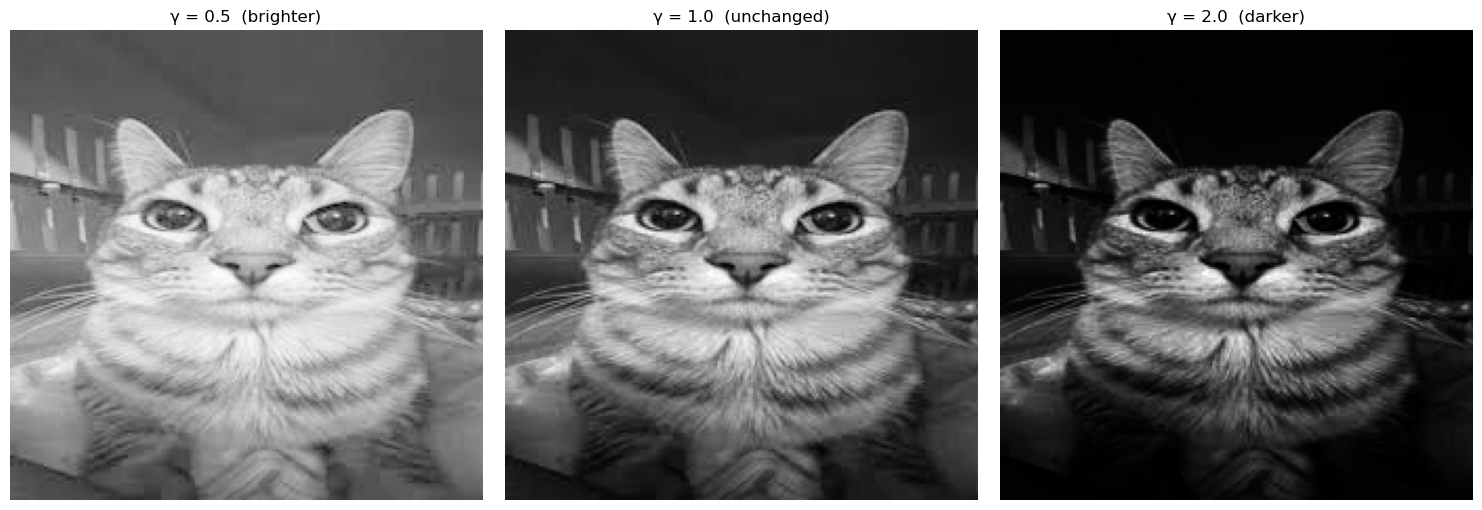

In [30]:
def gamma_correct(img_gray, gamma, c=1.0):
    norm = img_gray / 255.0
    corrected = np.clip(c * norm**gamma, 0, 1)
    return (corrected * 255).astype(np.uint8)

gamma_vals = [0.5, 1.0, 2.0]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, g in zip(axes, gamma_vals):
    ax.imshow(gamma_correct(img_gray, g), cmap='gray')
    label = 'brighter' if g < 1 else ('darker' if g > 1 else 'unchanged')
    ax.set_title(f'γ = {g}  ({label})')
    ax.axis('off')
plt.tight_layout()
plt.show()

### Task 4 – Intensity Slicing: Assign L−1 to Range [A, B]
Create a function that assigns `L−1 = 255` to all pixels whose intensity falls in [A, B],  
using `np.where()` as the equivalent of MATLAB's `find()`.

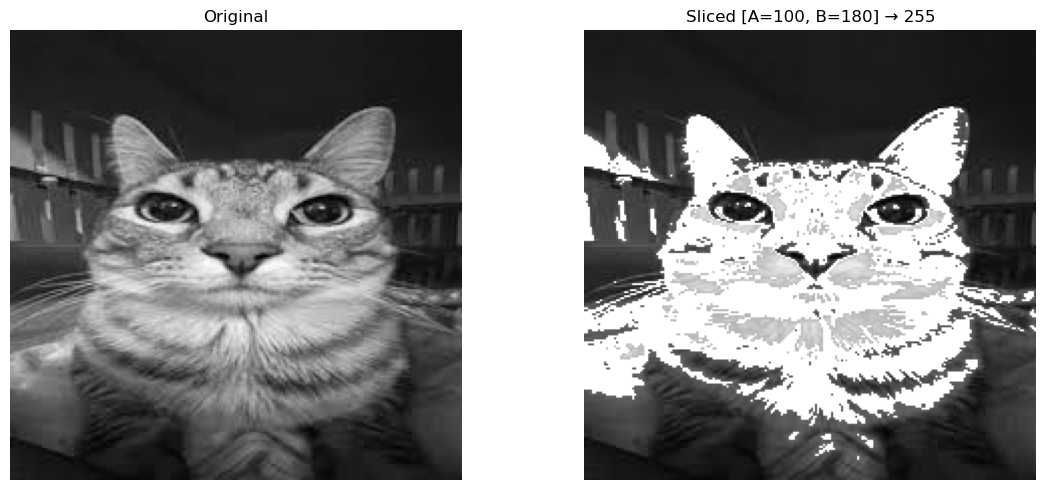

In [29]:
def intensity_slice(image, A, B, L=256):
    out = image.copy()
    idx = np.where((image >= A) & (image <= B))   # find() equivalent
    out[idx] = L - 1
    return out

A, B = 100, 180
sliced = intensity_slice(img_gray, A, B)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_gray, cmap='gray');  axes[0].set_title('Original');                          axes[0].axis('off')
axes[1].imshow(sliced,   cmap='gray');  axes[1].set_title(f'Sliced [A={A}, B={B}] → 255');    axes[1].axis('off')
plt.tight_layout()
plt.show()

### Task 5 – Enhance the Image
Apply appropriate transformations to improve the visual quality of the cat image.  
Strategy: histogram equalization (contrast stretch) + mild gamma brightening.

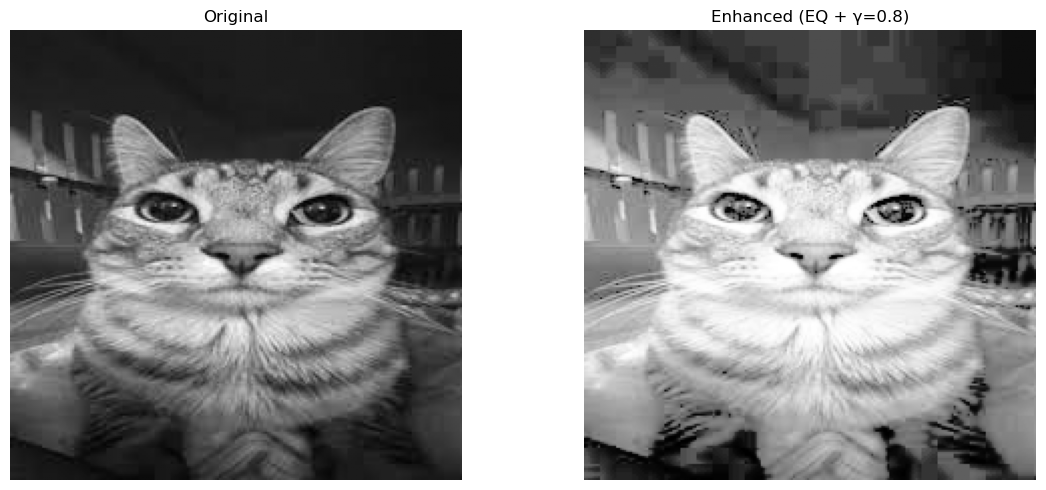

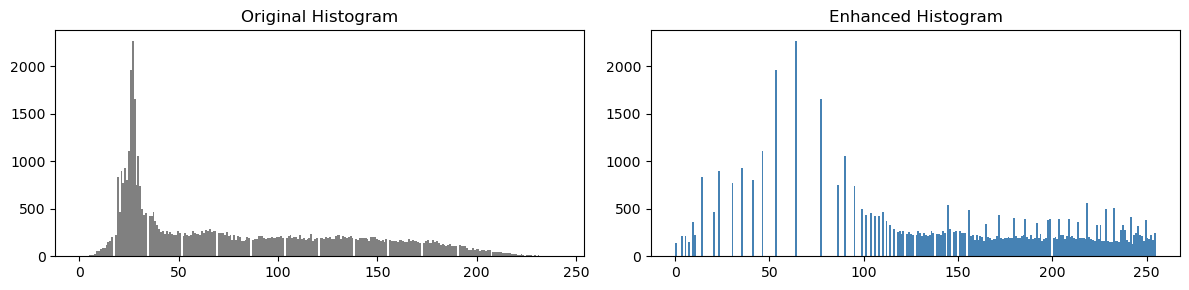

In [28]:
from PIL import ImageOps, ImageEnhance

def enhance_image(img_gray):
    pil_img = Image.fromarray(img_gray)
    equalized = ImageOps.equalize(pil_img)
    arr = np.array(equalized) / 255.0
    brightened = np.clip(arr ** 0.8, 0, 1)
    return (brightened * 255).astype(np.uint8)

enhanced = enhance_image(img_gray)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_gray,  cmap='gray'); axes[0].set_title('Original');                       axes[0].axis('off')
axes[1].imshow(enhanced,  cmap='gray'); axes[1].set_title('Enhanced (EQ + γ=0.8)');          axes[1].axis('off')
plt.tight_layout()
plt.show()

# Histogram comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(img_gray.ravel(), bins=256, color='gray');     axes[0].set_title('Original Histogram')
axes[1].hist(enhanced.ravel(), bins=256, color='steelblue'); axes[1].set_title('Enhanced Histogram')
plt.tight_layout()
plt.show()

### Task 6 – 'Images to Play With': Analyze Parameters
Explore the effect of different γ values on the cat image and visualize the results side by side.

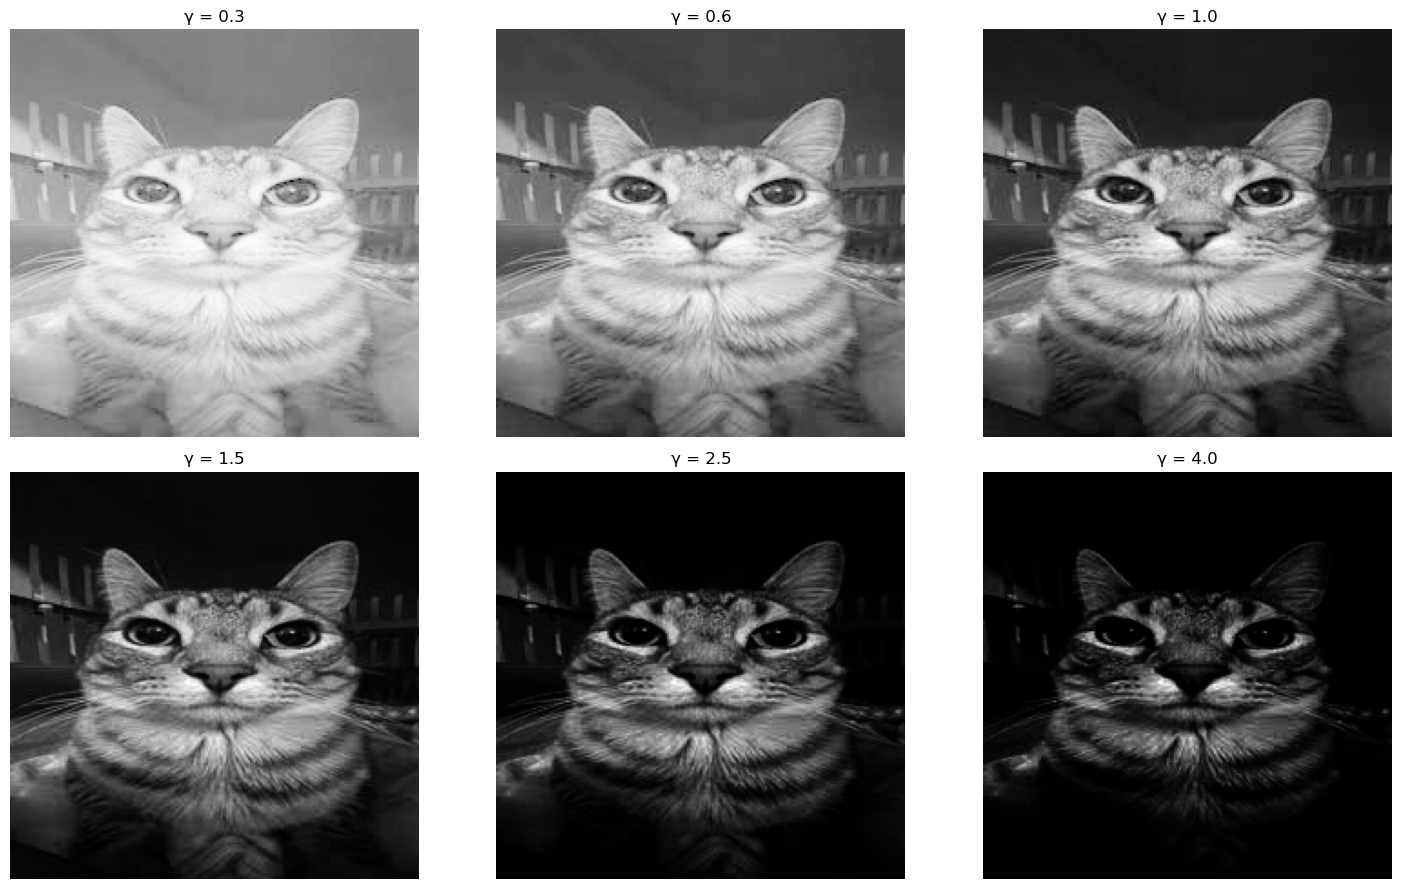

Reasonable parameters for cat.jpg:
  γ = 0.5–0.7 → good for brightening dark shadow areas
  γ = 1.0     → no change (baseline)
  γ = 1.5     → slight darkening, improves contrast in bright highlights


In [32]:
test_gammas = [0.3, 0.6, 1.0, 1.5, 2.5, 4.0]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, g in zip(axes.ravel(), test_gammas):
    ax.imshow(gamma_correct(img_gray, g), cmap='gray')
    ax.set_title(f'γ = {g}')
    ax.axis('off')
plt.tight_layout()
plt.show()
print('Reasonable parameters for cat.jpg:')
print('  γ = 0.5–0.7 → good for brightening dark shadow areas')
print('  γ = 1.0     → no change (baseline)')
print('  γ = 1.5     → slight darkening, improves contrast in bright highlights')

---
## Section 3: Bit-Plane Slicing

### Task 1 – `displayBitResponse` Function
Write a function that takes an image as input and displays **all 8 bit-plane binary images**.  
Each bit plane shows the contribution of one bit position to the final image.  
Equivalent to MATLAB's `bitget(image, i)`.

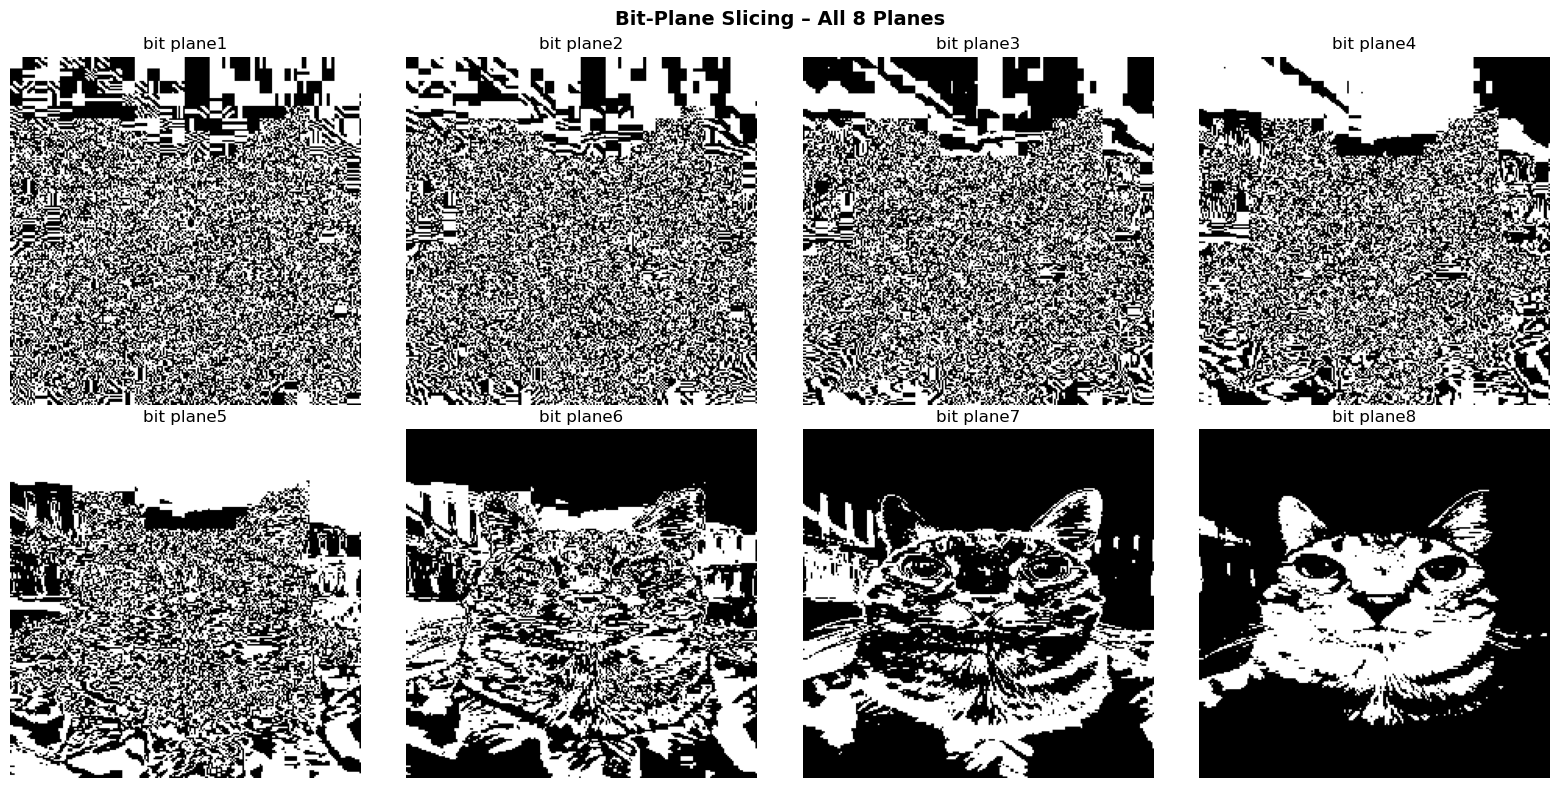

In [41]:
def displayBitResponse(image):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle('Bit-Plane Slicing – All 8 Planes', fontsize=14, fontweight='bold')
    for i in range(1, 9):
        ax = axes[(i-1)//4][(i-1)%4]
        bit_plane = (image >> (i - 1)) & 1    # bitget(image, i)
        ax.imshow(bit_plane * 255, cmap='gray')
        ax.set_title(f'bit plane{i}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

displayBitResponse(img_gray)

### Report

**Image Flipping:**  
Grayscale conversion collapses the 3-channel color space to a single luminance channel using perceptual weighting.  
The mirror effect is a horizontal reflection — mathematically equivalent to reversing the column indices.

**Intensity Transformation:**  
The power-law (gamma) transformation `s = cr^γ` is the most versatile tool in this lab.  
The critical insight about normalization: on [0,1] the endpoint `r=1` always maps to `s=1` regardless of γ,  
while on [0,255] values above 1 raised to powers >1 grow without bound.

**Bit-Plane Slicing:**  
The most significant bits (planes 7–8) carry the bulk of the visual information and can alone reconstruct a  
recognizable image. The least significant bits (planes 1–3) contribute fine intensity variations and appear  
as random noise — this is exploited in image compression and steganography.
